In [1]:
import rasterio
from rasterio.plot import show
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pyproj import Transformer

In [25]:
cog_file_path = "ASC_EV_C_P_AU_TRN_N.cog.tif"
with rasterio.open(cog_file_path) as dataset:
    # Define the window for the bottom of the COG
    width = dataset.width
    height = dataset.height
    print("Metadata:", dataset.meta)
    data_crs = dataset.crs
    res = dataset.res
    transformation = dataset.transform
    band1 = dataset.read(1)

Metadata: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 49200, 'height': 40800, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0008333333333536583, 0.0, 112.999583333,
       0.0, -0.0008333333333578432, -10.000416666)}


In [33]:
# print(data_crs)
# data_crs = rasterio.crs.CRS.to_dict(data_crs)
# data_crs


EPSG:4326


{'proj': 'longlat', 'datum': 'WGS84', 'no_defs': True}

In [3]:
res

(0.0008333333333536583, 0.0008333333333578432)

In [34]:
dataset = pd.DataFrame(band1)
dataset

,0,1,2,3,4,5,6,7,8,9,...,49190,49191,49192,49193,49194,49195,49196,49197,49198,49199
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40795,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40796,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40797,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40798,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
#dataset.rename(columns=lambda a : a*res[0])

,0.000000,0.000833,0.001667,0.002500,0.003333,0.004167,0.005000,0.005833,0.006667,0.007500,...,40.991667,40.992500,40.993333,40.994167,40.995000,40.995833,40.996667,40.997500,40.998333,40.999167
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40795,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40796,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40797,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40798,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
#dataset.rename(index=lambda a : a*res[1])

,0,1,2,3,4,5,6,7,8,9,...,49190,49191,49192,49193,49194,49195,49196,49197,49198,49199
0.000000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0.000833,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0.001667,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0.002500,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0.003333,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33.995833,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33.996667,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33.997500,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33.998333,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
transformation = np.array(transformation)
transformation = np.reshape(transformation, (3,3))
transformation

array([[ 8.33333333e-04,  0.00000000e+00,  1.12999583e+02],
       [ 0.00000000e+00, -8.33333333e-04, -1.00004167e+01],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])

In [37]:
dataset.rename(columns=lambda a : a*transformation[0,0]+transformation[0,2], inplace=True)

In [38]:
dataset.rename(index=lambda a : a*transformation[1,1]+transformation[1,2], inplace=True)

In [41]:
dataset.shape[0]

40800

In [84]:
n=50
smaller_dataset = dataset.iloc[range(0,dataset.shape[0],n),range(0,dataset.shape[1],n)]

In [85]:
smaller_dataset['latitude']=smaller_dataset.index

In [86]:
smaller_dataset = smaller_dataset.melt(id_vars='latitude', var_name='longitude')

In [87]:
smaller_dataset = smaller_dataset[smaller_dataset.value != 0]

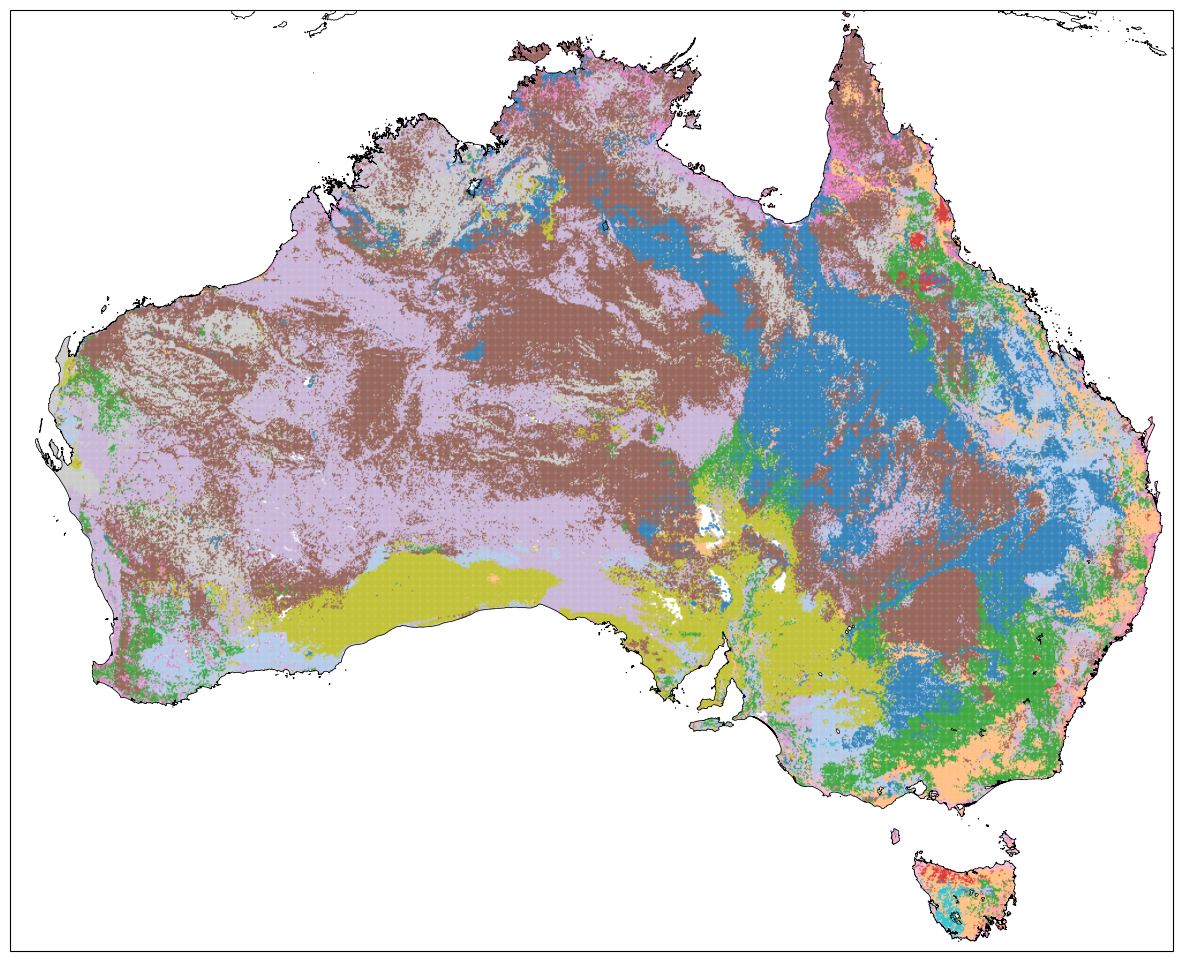

In [114]:
from mpl_toolkits.basemap import Basemap
coordinates = (112, 154, -44, -10)

plt.figure(figsize=(15, 15))
m = Basemap(
    llcrnrlon=coordinates[0], llcrnrlat=coordinates[2],
    urcrnrlon=coordinates[1], urcrnrlat=coordinates[3],
    resolution='f')
ax = plt.axes(projection=ccrs.PlateCarree())
m.drawcoastlines(linewidth=.5)
ax.scatter(smaller_dataset['longitude'], smaller_dataset['latitude'], s=0.1, c=smaller_dataset['value'], cmap='tab20')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.show()